# Experimento Q-Learning

## Pergunta

Será que, ao adaptar algoritmos de Aprendizado por Reforço conhecidos com o uso de marcadores somáticos, serão produzidos ganhos em agilidade e acurácia em sistemas computacionais semelhantes aos observados nos seres vivos?

## Hipóteses

Os marcadores somáticos contribuem para a agilidade e acurácia do Aprendizado por Reforço.

## Testes

### Resolver o FrozenLake

Treinar dois Agentes: um Q-Learning e outro Q-Learning com marcadores somáticos.

Variável Teórica: Agilidade => Variável Operacional: Quantidade de episódios de treinamento até estabilizar a resposta 

Variável Teórica: Acurácia => Variável Operacional: Percentual de sucesso na execução do agente com a tabela Q treinada, porém com um tabuleiro ligeiramente diferente.

Resultado esperado: o Agente Q-Learning somático deve estabilizar em menos episódios de treinamento e possuir um percentual maior de acerto num tabuleiro diferente.



In [1]:
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import pickle

import gymnasium as gym
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

from Agent import *

from Util import *


sns.set_theme()

In [2]:
#total_episodes=5000
learning_rate=0.8
gamma=0.95
epsilon=0.1
n_runs=20

#somatic parameters
la = 0.6
ld = -0.6
d = 0.8
f = 1

In [3]:
def run_training(total_episodes, agent:Agent):

    rewards = np.zeros((total_episodes, n_runs))
    steps = np.zeros((total_episodes, n_runs))
    episodes = np.arange(total_episodes)
    qtables = np.zeros((n_runs, agent.getStateSize(), agent.getActionSize()))
    all_states = []
    all_actions = []
    
    for run in range(n_runs):  # Run several times to account for stochasticity
        agent.reset_qtable()  # Reset the Q-table between runs

        if isinstance(agent,SomaticQLearning):
            agent.set_somaticMemory({}) #Reset somatic memory too

        for episode in tqdm(
            episodes, desc=f"Run {run}/{n_runs} - Episodes", leave=False
            ):
            agent.setTraningMode(learning_rate,gamma,epsilon)
            agent.reset()        
            step = 0
            done = False
            total_rewards = 0

            while not done:
                state, action, _, reward = agent.step()

                # Log all states and actions
                all_states.append(state)
                all_actions.append(action)

                done = agent.done()

                total_rewards += reward
                step += 1

            # Log all rewards and steps
            rewards[episode, run] = total_rewards
            steps[episode, run] = step
        qtables[run, :, :] = agent.getQTable()

    return rewards, steps, episodes, qtables, all_states, all_actions

## TREINAMENTO

MAP SIZE 8 ##############################################
CLASSIC Q-LEARNING ##############################################


<frozen importlib._bootstrap>:488: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.


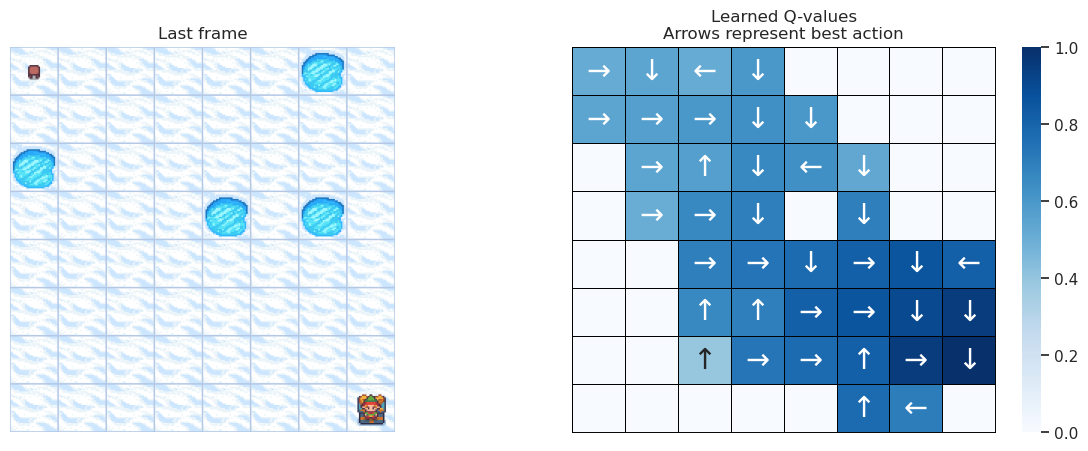

SOMATIC Q-LEARNING ##############################################


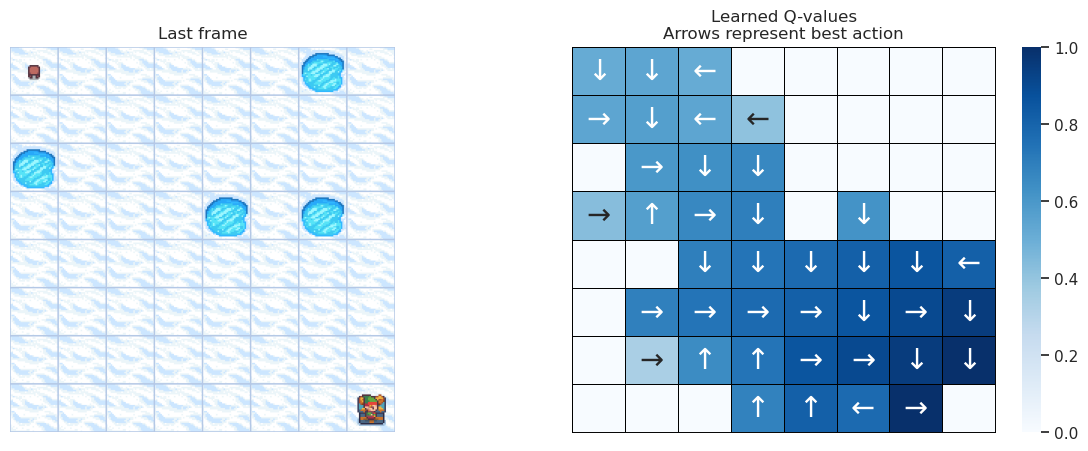

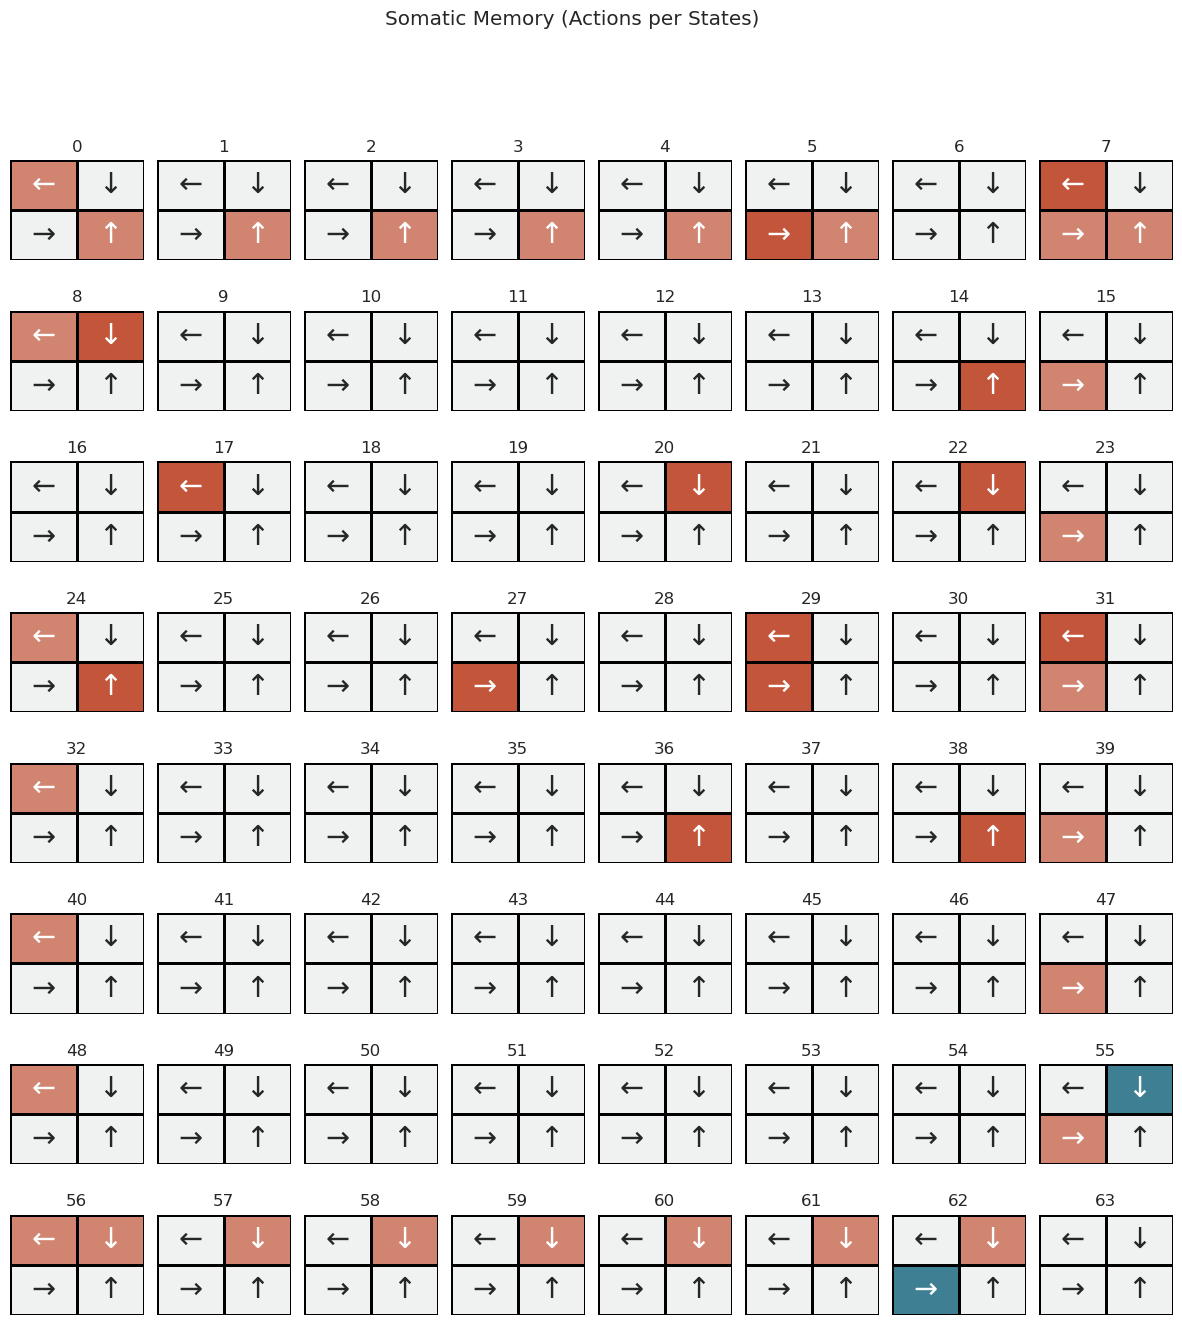

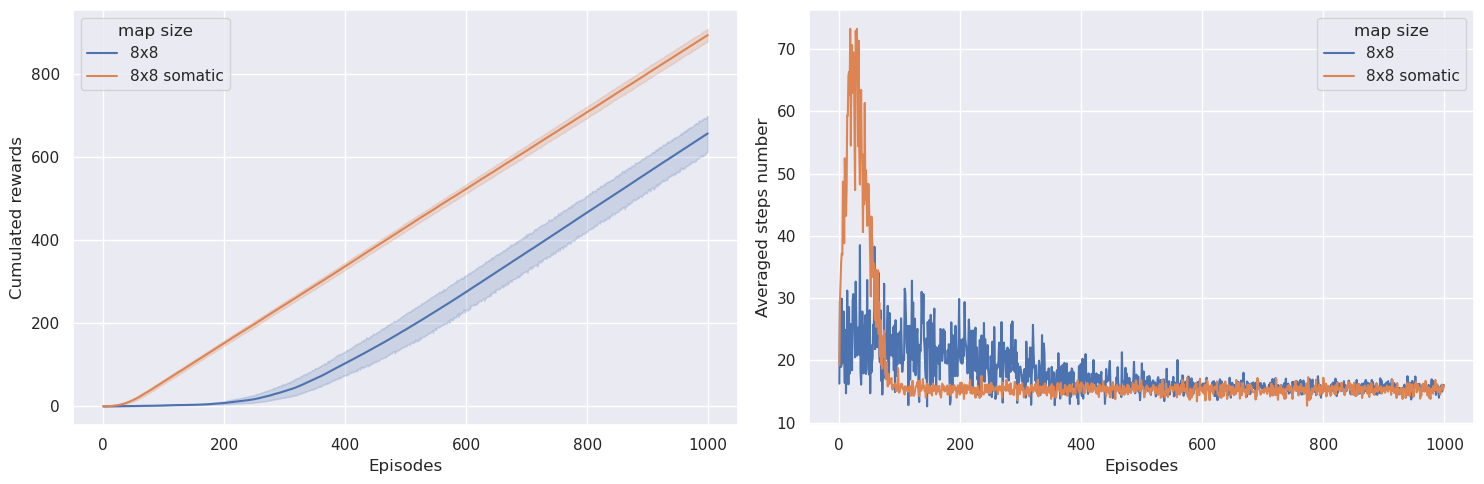

MAP SIZE 10 ##############################################
CLASSIC Q-LEARNING ##############################################


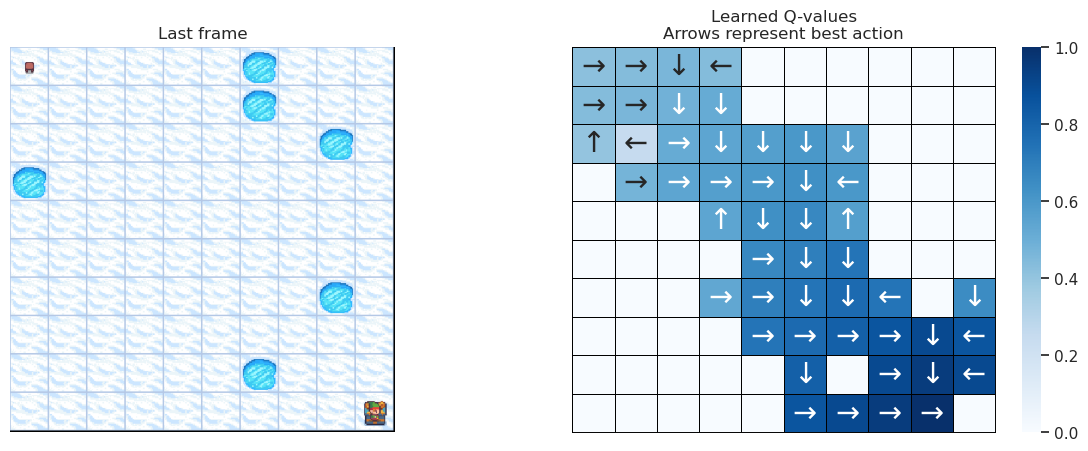

SOMATIC Q-LEARNING ##############################################


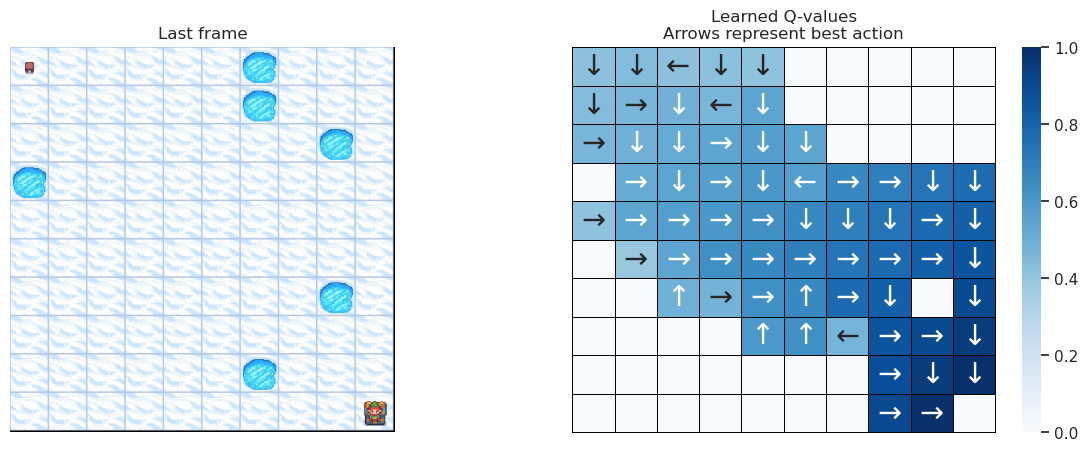

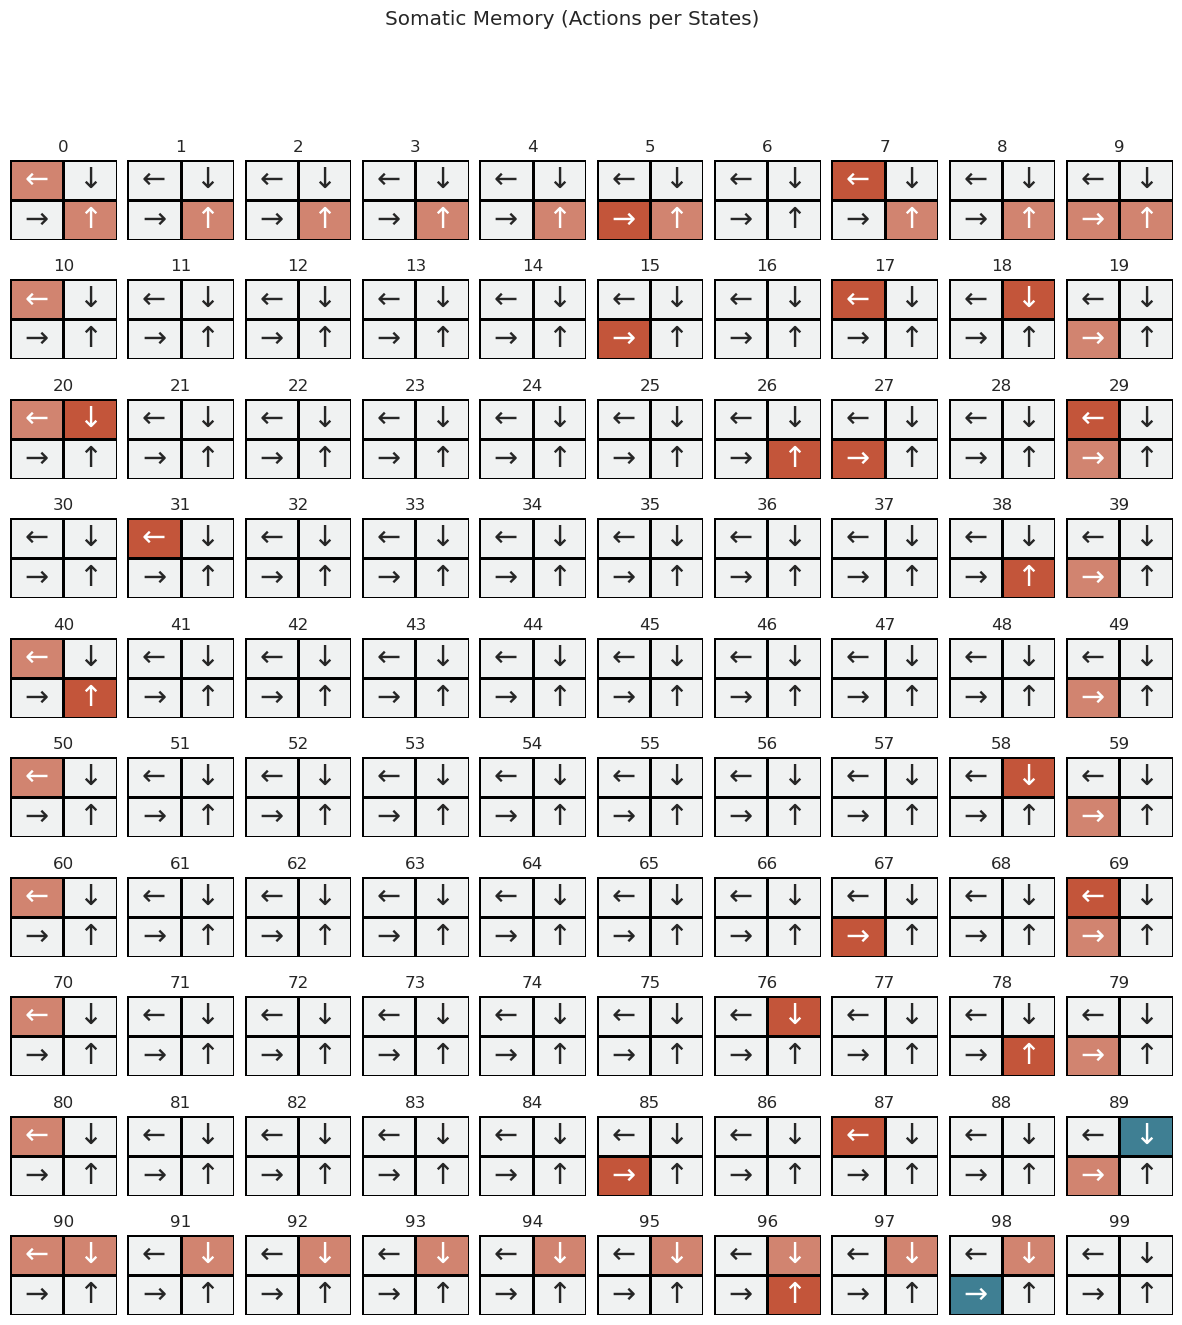

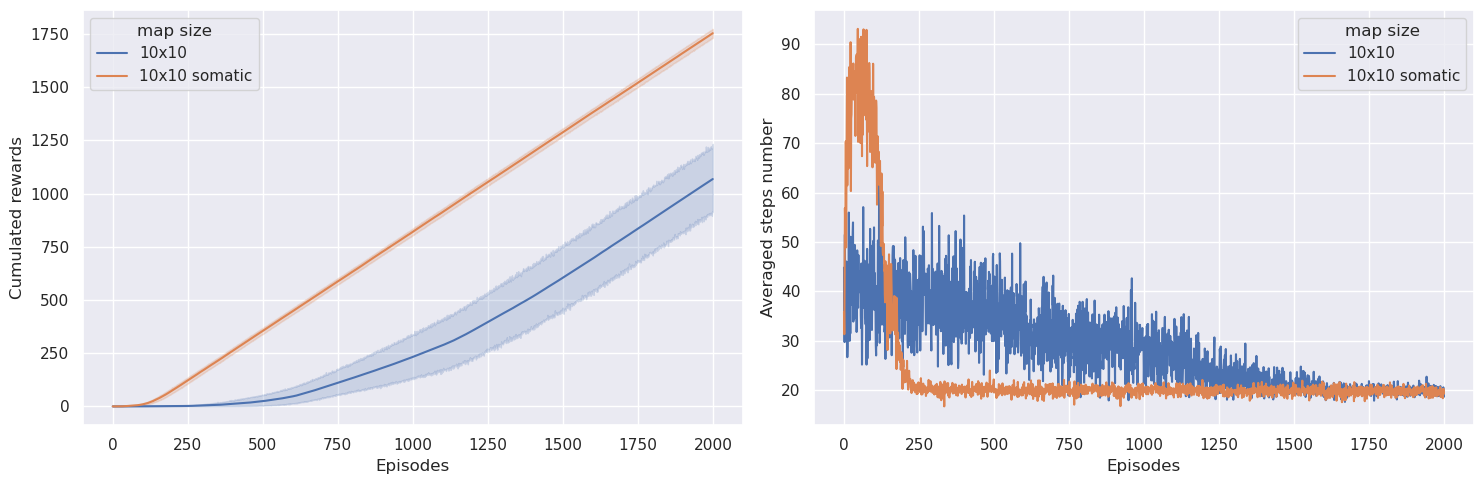

MAP SIZE 12 ##############################################
CLASSIC Q-LEARNING ##############################################


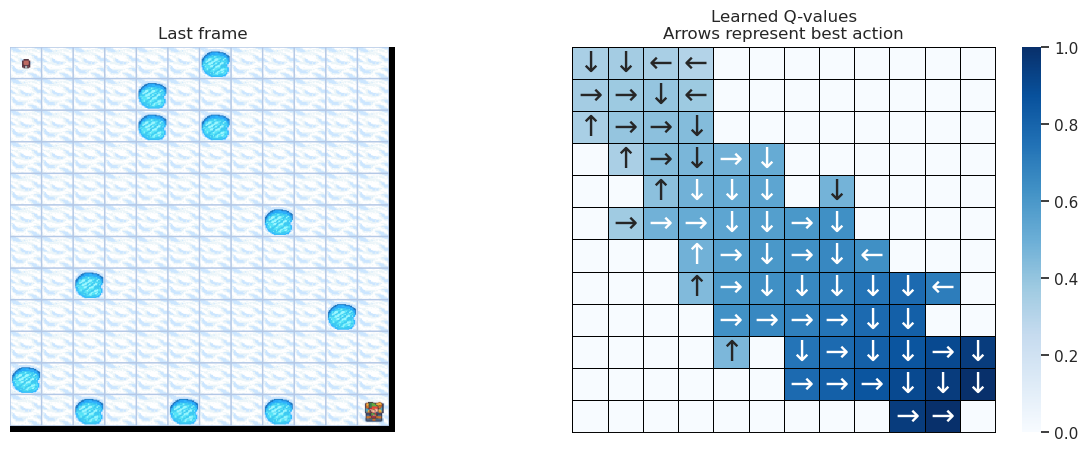

SOMATIC Q-LEARNING ##############################################


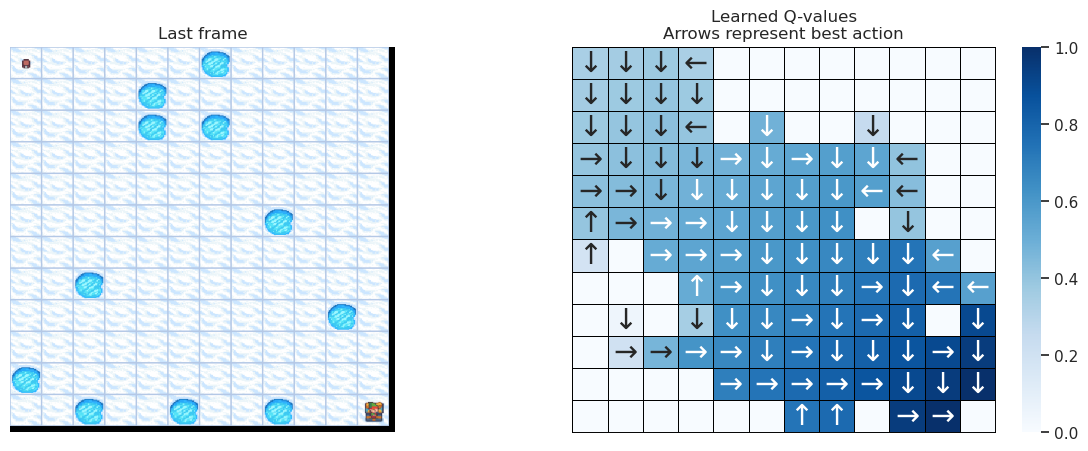

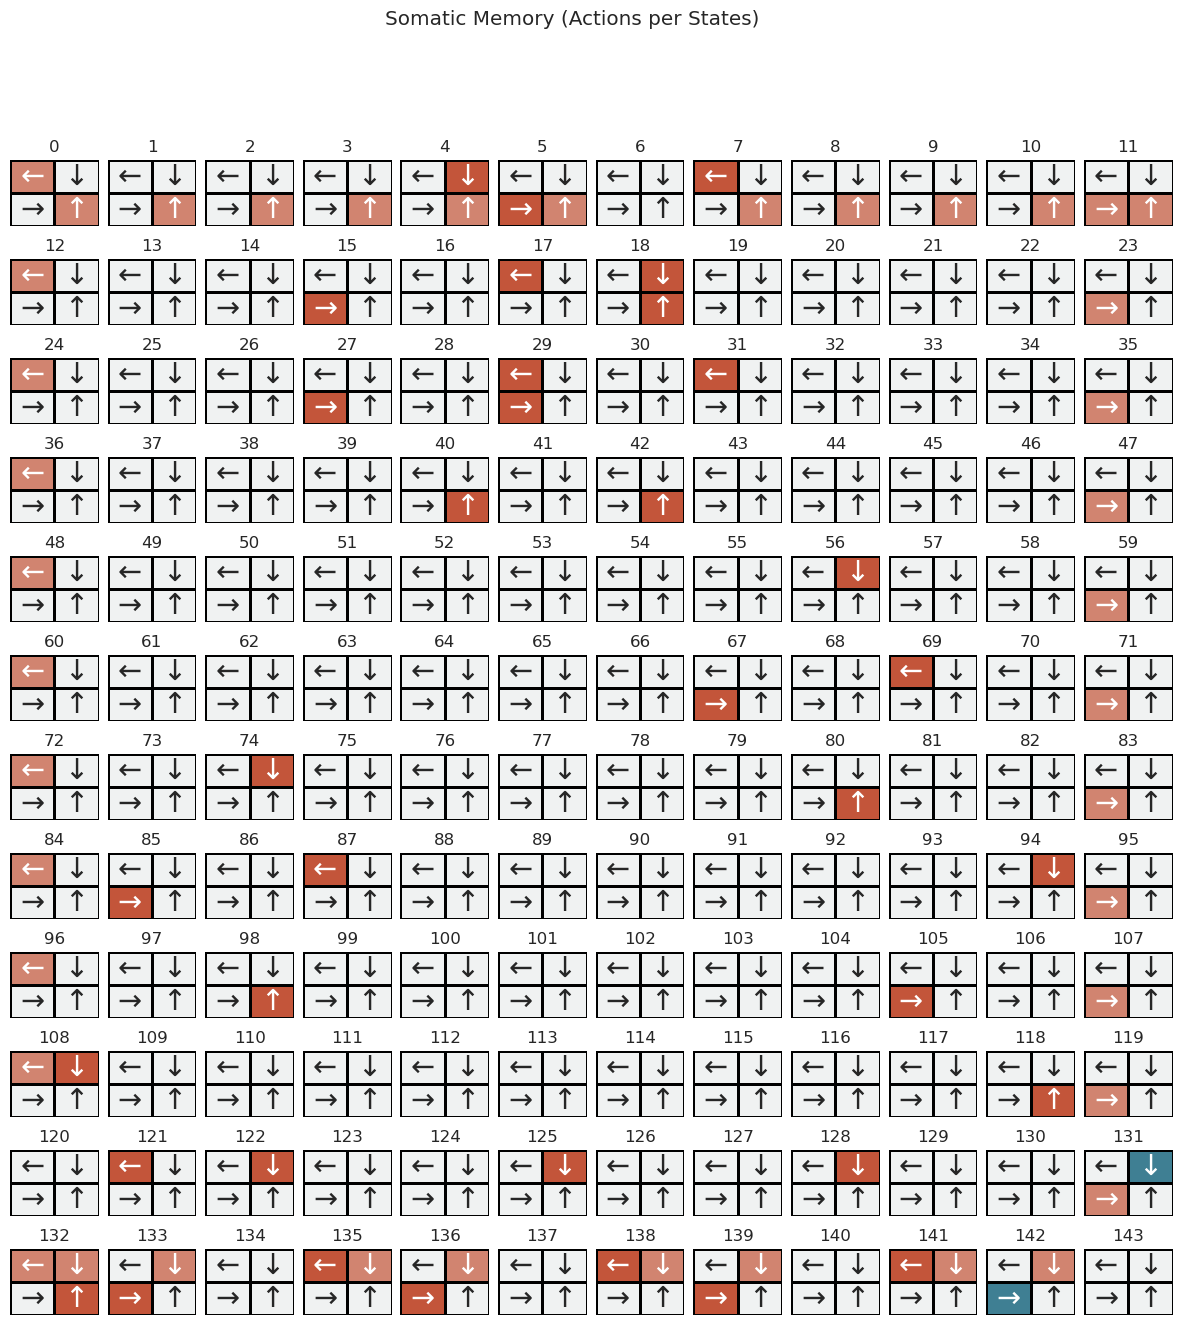

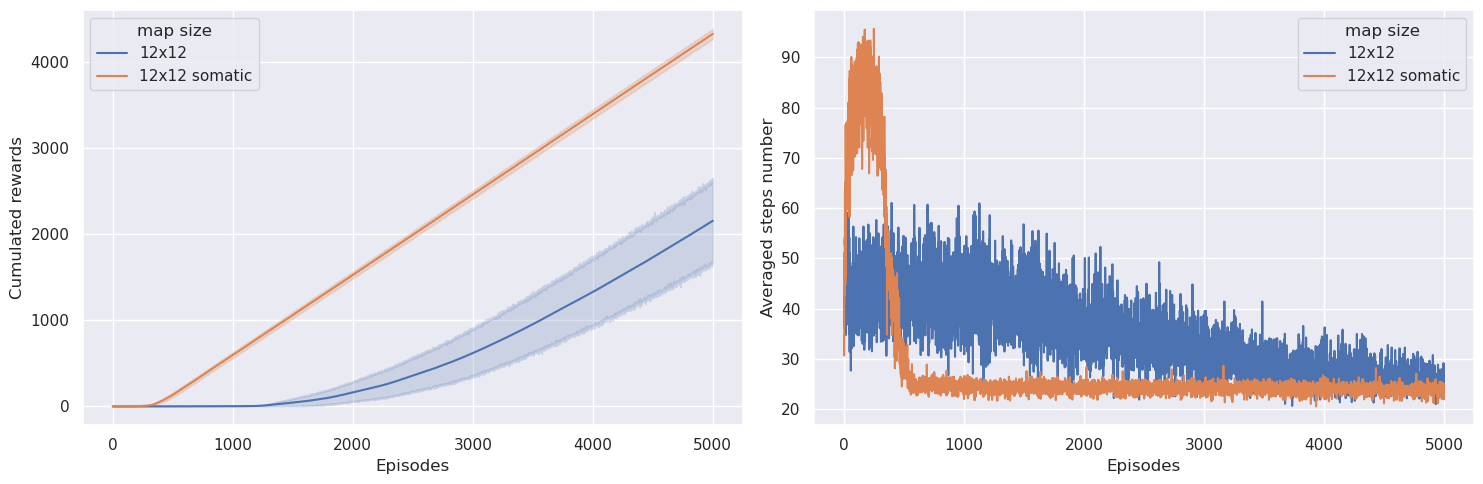

In [4]:
#(size, episodes)
map_sizes = [(8,1000), (10, 2000), (12, 5000)]

for map_size, total_episodes in map_sizes:
    res_all = pd.DataFrame()
    st_all = pd.DataFrame()

    with open(f"maps/{map_size}x{map_size}.pkl", 'rb') as inf: 
        map = pickle.load(inf) 
    
    print("MAP SIZE {} ##############################################".format(map_size))

    env = gym.make(
        "FrozenLake-v1",
        is_slippery=False,
        render_mode="rgb_array",
        desc=map,
    )

    #### Q-LEARNING #####################################################################################
    print("CLASSIC Q-LEARNING ##############################################")
    agent = QLearning(env)

    rewards, steps, episodes, qtables, all_states, all_actions = run_training(total_episodes,agent)

    # Save the results in dataframes
    res, st = postprocess(episodes, n_runs, rewards, steps, map_size, False)
    res_all = pd.concat([res_all, res])
    st_all = pd.concat([st_all, st])

    #qtable = qtables.mean(axis=0)  # Average the Q-table between runs

    plot_q_values_map(agent.getQTable(), env, map_size)

    # Save Q-Table
    with open(f"data/qtable{map_size}.pkl", 'wb') as outf:
        pickle.dump(agent.getQTable(), outf) 


    #### SOMATIC Q-LEARNING ##########################################################################
    print("SOMATIC Q-LEARNING ##############################################")
    somaticAgent = SomaticQLearning(env,la,ld,d,f)

    rewards, steps, episodes, qtables, all_states, all_actions = run_training(total_episodes,somaticAgent)

    # Save the results in dataframes
    res, st = postprocess(episodes, n_runs, rewards, steps, map_size, True)
    res_all = pd.concat([res_all, res])
    st_all = pd.concat([st_all, st])

    #qtable = qtables.mean(axis=0)  # Average the Q-table between runs

    # Save Q-Table
    with open(f"data/qtable{map_size}_s.pkl", 'wb') as outf:
        pickle.dump(somaticAgent.getQTable(), outf) 

    # Save Somatic Memory
    with open(f"data/sm{map_size}.pkl", 'wb') as outf:
        pickle.dump(somaticAgent.get_somaticMemory(), outf) 

    plot_q_values_map(somaticAgent.getQTable(), env, map_size)

    plot_somatic_memory(map_size, somaticAgent.get_somaticMemory())

    env.close()

    plot_steps_and_rewards(res_all,st_all)

## 8x8 (ideal 14 passos)

O algoritmo QL converge em aproximadamente 15 passos, no episódio 450.

O QL Somático converge nos mesmos 15 passos, no episódio 50.


## 10x10 (ideal 18 passos)

O algoritmo QL converge em aproximadamente 20 passos, em 1500 episódios.

O QL Somático converge nos mesmos 20 passos, em 200 episódios.

## 12x12 (ideal 22 passos)

O algoritmo QL converge não consegue convergir em 5000 episódios.

O QL Somático converge em aproximadamente 23 passos, em 500 episódios.